In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch import Tensor
import os

import gym
import numpy as np
np.bool8 = np.bool_

import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

from itertools import count
from typing import Union, Tuple, Callable

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## Task 1: Replay Buffer

In [2]:
class ReplayBuffer(object):
    def __init__(self, size: int = 10000):
        """
        Constructor
        
        Parameters
        ----------
        size
            Maximum number of transitions store in the buffer.
            If the buffer overflows, older states are dropped.
        """
        self.size    = size
        self.length  = 0
        self.idx     = -1
        
        # define buffers
        self.states        = None
        self.states_next   = None
        self.actions       = None
        self.rewards       = None
        self.done          = None
        
    def store(self, 
              s: Union[torch.Tensor, np.ndarray], 
              a: int, 
              r: float, 
              s_next: Union[torch.Tensor, np.ndarray],
              done: bool):
        
        """
        Stores one sample of experience
        
        Parameters
        ----------
        s
            Tensor encoding the current state.
        a
            Current action.
        r
            Current reward.
        s_next
            Tensor encoding the next state.
        done
            Done signal.
        """
        
        # initialize buffers
        if self.states is None:
            self.states      = torch.zeros([self.size] + list(s.shape))   # shape is (self.size, 4)
            self.states_next = torch.zeros_like(self.states)              # shape is (self.size, 4)
            self.actions     = torch.zeros((self.size, ))                 # shape is (self.size, )
            self.rewards     = torch.zeros((self.size, ))                 # shape is (self.size, )
            self.done        = torch.zeros((self.size, ))                 # shape is (self.size, ) 
        
        # TODO: store current (s, a, r, s_next, done) behavior sample in the corresponding tensor buffers
        # Note 1: older instances are overwritten if the buffer overflows.
        # Note 2: increment buffer length after each update, until it reaches the maximum allowed value: self.size
        self.idx = (self.idx + 1) % self.size
        
        self.states[self.idx] = torch.as_tensor(s)
        self.states_next[self.idx] = torch.as_tensor(s_next)
        self.actions[self.idx] = a
        self.rewards[self.idx] = r
        self.done[self.idx] = float(done)

        # Update length until it reaches max size [cite: 40, 71]
        if self.length < self.size:
            self.length += 1

        
    def sample(self, batch_size: int = 128) -> Tuple[Tensor, Tensor, Tensor, Tensor, Tensor]:
        """
        Sample a batch of experience
        
        Parameters
        ----------
        batch_size
            Number of experience to sample
            
        Returns
        -------
        Tuple of tensor consisting of a batch of states, actions, rewards, next states, done
        """
        
        assert self.length >= batch_size, "Can not sample from the buffer yet"
        indices = np.random.choice(a=np.arange(self.length), size=batch_size, replace=False)
        
        # Sample (s, a, r, s_next, done) behavior samples   
        # s      = ...         (batch_size, 4)
        # s_next = ...    (batch_size, 4)
        # a = ...              (batch_size, )
        # r = ...               (batch_size, )
        # done = ...    (batch_size, )
        s = self.states[indices]
        s_next = self.states_next[indices]
        a = self.actions[indices]
        r = self.rewards[indices]
        done = self.done[indices]
        
        return s, a, r, s_next, done

## Network achitecture

In [3]:
class DQN_RAM(nn.Module):
    def __init__(self, in_features: int, num_actions: int):
        """
        Initialize a deep Q-learning network for testing algorithm
        
        Parameters
        ----------
        in_features
            number of features of input.
        num_actions
            number of action-value to output, one-to-one correspondence to action in game.
        """
        super(DQN_RAM, self).__init__()
        self.in_features = in_features
        self.num_actions = num_actions
        
        # define architecture
        self.fc1 = nn.Linear(in_features, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, num_actions)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

## Epsilon scheduler

In [4]:
def eps_generator(max_eps: float=0.9, min_eps: float=0.05, max_iter: int = 10000):
    crt_iter = -1
    
    while True:
        crt_iter += 1
        frac = min(crt_iter/max_iter, 1)
        eps = (1 - frac) * max_eps + frac * min_eps
        yield eps

## Epsilon greedy policy

In [5]:
def select_epilson_greedy_action(Q: nn.Module, s: Tensor, eps: float):
    rand = np.random.rand()
    
    # with prob eps select a random action
    if rand < eps:
        return np.random.choice(np.arange(Q.num_actions))
    
    # select best action
    with torch.no_grad():
        output = Q(s).argmax(dim=1).item()
    
    return output

## Task 2: DQN target

In [6]:
@torch.no_grad()
def dqn_target(
    Q: nn.Module,
    target_Q: nn.Module,
    r_batch: Tensor,
    s_next_batch: Tensor,
    done_batch: Tensor,
    gamma: float) -> Tensor:
    """
    Computes DQN target
    
    Parameters:
    -----------
    Q
        Behavior Q network.
    target_Q
        Target Q network.
    r_batch
        Batch of rewards.
    s_next_bacth
        Batch of next states.
    done_batch
        Batch of done flag (1 means the episoded finished).
    gamma
        Discount factor.
    
    Returns
    -------
    Batch of DQN targets
    """
    # cmpute next Q value based on which action gives max Q values
    # Note:  decorator torch.no_grad() ensures that gradients computed based on next Q are not propagated to the target_Q network
    # Note: take note of the done_batch values - if behavior sample i in the batch has a done flag (done_batch[i] = 1), then the next_Q_values[i] 
    #             will only consider the reward[i] (because there is no next_state)
    
    next_Q_values = target_Q(s_next_batch).max(dim=1)[0]
    next_Q_values = next_Q_values * (1 - done_batch)
    
    return r_batch + (gamma * next_Q_values)

## Task 3: DDQN target

$target_t = R_{t+1} + \gamma Q_{target}(S_{t+1}, \underset{a}{\operatorname{argmax}} Q(S_{t+1}, a; \theta_{t}); \theta_t^{-})$

In [7]:
@torch.no_grad()
def ddqn_target(
    Q: nn.Module,
    target_Q: nn.Module,
    r_batch: Tensor,
    s_next_batch: Tensor,
    done_batch: Tensor,
    gamma: float) -> Tensor:
    """
    Computes DQN target
    
    Parameters:
    -----------
    Q
        Behavior Q network.
    target_Q
        Target Q network.
    r_batch
        Batch of rewards.
    s_next_bacth
        Batch of next states.
    done_batch
        Batcho of done flag (1 means the episoded finished).
    gamma
        Discount factor.
    
    Returns
    -------
    Batch of DQN targets
    """
    # compute next Q value based on which action gives max Q values
    best_actions = Q(s_next_batch).argmax(dim=1, keepdim=True)
    next_Q_values = target_Q(s_next_batch).gather(1, best_actions).squeeze(1)
    next_Q_values = next_Q_values * (1 - done_batch)
    
    # Compute the target of the current Q values
    return r_batch + (gamma * next_Q_values)

##  Learning Alogrithm

In [8]:
def learning(
    env: gym.Env,
    target_function: Callable,
    batch_size: int = 128,
    gamma: float = 0.99,
    replay_buffer_size=10000,
    num_episodes: int = 100000,
    learning_starts: int = 1000,
    learning_freq: int = 4,
    learning_rate: float = 1e-3,
    target_update_freq: int = 100,
    eps_decay_steps: int = 10000,
    log_every: int = 100):

    """
    DQN Learning
    
    Parameters
    ----------
    env
        gym environment to train on.
    target_function
        Function that computes the Q network target. For DQN - dqn_target, for DDQN - ddqn_target.
    batch_size:
        How many transitions to sample each time experience is replayed.
    gamma
        Discount Factor
    replay_buffer_size
        Replay buffer size.
    num_episodes
        number of episodes to run
    learning_starts: int
        After how many environment steps to start replaying experiences
    learning_freq: int
        How many steps of environment to take between every experience replay
    target_update_freq: int
        How many experience replay rounds (not steps!) to perform between
        each update to the target Q network
    log_every:
        Logging interval
    """
    # This means we are running on low-dimensional observations (e.g. RAM)
    input_arg = env.observation_space.shape[0]
    num_actions = env.action_space.n

    # define device 
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Initialize target q function and q function
    Q = DQN_RAM(input_arg, num_actions).to(device)
    target_Q = DQN_RAM(input_arg, num_actions).to(device)
      
    # Construct Q network optimizer function
    optimizer = optim.Adam(Q.parameters(), lr=learning_rate)
    
    # define criterion
    criterion = nn.MSELoss()

    # Construct the replay buffer
    replay_buffer = ReplayBuffer()
    
    # define epsilon scheduler
    eps_scheduler = iter(eps_generator(max_eps=0.9, min_eps=0.05, max_iter=eps_decay_steps))
    
    # define statistics buffer, total number of steps and total number of updates performed
    all_episode_rewards = []
    total_steps = 0
    num_param_updates = 0
    
    for episode in range(1, num_episodes + 1):
        # reset environment
        s, _ = env.reset()
        episode_reward = 0
        
        for _ in count():
            # increse total number of steps
            total_steps += 1
            
            # Choose random action if not yet start learning
            if total_steps > learning_starts:
                eps = next(eps_scheduler)
                s = torch.tensor(s).view(1, -1).float().to(device)
                a = select_epilson_greedy_action(Q, s, eps)
            else:
                a = np.random.choice(np.arange(num_actions))

            # advance one step
            s_next, r, terminated, truncated, _ = env.step(a)
            done = terminated or truncated
            
            # update episode rewards
            episode_reward += r

            # store other info in replay memory
            replay_buffer.store(s, a, r, s_next, done)

            # Resets the environment when reaching an episode boundary.
            if done:
                break

            # update state
            s = s_next

            # perform experience replay and train the network.
            if (total_steps > learning_starts and total_steps % learning_freq == 0):
                for _ in range(learning_freq):
                    # sample experinence from the replay buffer
                    s_batch, a_batch, r_batch, s_next_batch, done_batch = replay_buffer.sample(batch_size)

                    # send everything to device
                    s_batch      = s_batch.float().to(device)
                    a_batch      = a_batch.long().to(device)
                    r_batch      = r_batch.float().to(device)
                    s_next_batch = s_next_batch.float().to(device)
                    done_batch   = done_batch.long().to(device)

                    # comput the q values according to the states and actions
                    Q_values = Q(s_batch).gather(1, a_batch.unsqueeze(1)).view(-1)

                    # Compute the target of the current Q values
                    target_Q_values = target_function(Q, target_Q, r_batch, s_next_batch, done_batch, gamma)

                    # compute loss
                    loss = criterion(target_Q_values, Q_values)

                    # Clear previous gradients before backward pass
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()

                    # increase number of updates
                    num_param_updates += 1

                    # Periodically update the target network by Q network to target Q network
                    if num_param_updates % target_update_freq == 0:
                        target_Q.load_state_dict(Q.state_dict())

        # append total reward culumated
        all_episode_rewards.append(episode_reward)
        
        # log average reward over the last 100 episodes
        if episode % log_every == 0 and total_steps > learning_starts:
            mean_episode_reward = np.mean(all_episode_rewards[-100:])
            print("Episode: %d, Mean reward: %.2f, Eps: %.2f" % (episode, mean_episode_reward, eps))

    return all_episode_rewards


## DQN Learning

#### Task 4a: Modify learning procedure to implement original DQN (model and target networks are the same)
#### Task 4b: Modify learning procedure to implement target network DQN

**Note: Experiment with different values of:**
  - learning_freq
  - target_update_frequency
  - epsilon decay rate

In [ ]:
# # initialize gym env
# env = gym.make("CartPole-v1", max_episode_steps=100)

# # DQN learning
# dqn_rewards = learning(
#     env=env,                          # gym environmnet
#     target_function=dqn_target,      # dqn target construction
#     batch_size=128,                   # q-network update batch size
#     gamma=0.99,                       # discount factor
#     replay_buffer_size=10000,         # size of the replay buffer
#     num_episodes=1000,                # number of episodes to run
#     learning_starts=1000,             # number of initial random actions (exploration)
#     learning_freq=4,                  # frequency of the update
#     target_update_freq=1,           # number of gradient steps after which the target network is updated
#     log_every=100                     # logging interval. returns the mean reward per episode.
# )

Episode: 100, Mean reward: 22.17, Eps: 0.89
Episode: 200, Mean reward: 55.08, Eps: 0.39
Episode: 300, Mean reward: 97.55, Eps: 0.10
Episode: 400, Mean reward: 82.33, Eps: 0.10
Episode: 500, Mean reward: 94.32, Eps: 0.10
Episode: 600, Mean reward: 97.22, Eps: 0.10
Episode: 700, Mean reward: 99.34, Eps: 0.10
Episode: 800, Mean reward: 93.68, Eps: 0.10
Episode: 900, Mean reward: 97.11, Eps: 0.10
Episode: 1000, Mean reward: 98.86, Eps: 0.10


## DDQN Learning
**Note: Experiment with different values of:**
  - learning_freq
  - target_update_frequency
  - epsilon decay rate

In [ ]:
# # initialize gym env
# env = gym.make("CartPole-v1", max_episode_steps=100)

# # DQN learning
# ddqn_rewards = learning(
#     env=env,                          # gym environmnet
#     target_function=ddqn_target,     # dqn target construction
#     batch_size=128,                   # q-network update batch size
#     gamma=0.99,                       # discount factor
#     replay_buffer_size=10000,         # size of the replay buffer
#     num_episodes=1000,                # number of episodes to run
#     learning_starts=1000,             # number of initial random actions  (exploration)
#     learning_freq=4,                  # frequency of the update
#     target_update_freq=100,           # number of gradient steps after which the target network is updated
#     log_every=100                     # logging interval. returns the mean reward per episode.
# )

Episode: 100, Mean reward: 25.10, Eps: 0.86
Episode: 200, Mean reward: 39.37, Eps: 0.51
Episode: 300, Mean reward: 76.35, Eps: 0.10
Episode: 400, Mean reward: 98.38, Eps: 0.10
Episode: 500, Mean reward: 95.20, Eps: 0.10
Episode: 600, Mean reward: 97.82, Eps: 0.10
Episode: 700, Mean reward: 95.87, Eps: 0.10
Episode: 800, Mean reward: 93.61, Eps: 0.10
Episode: 900, Mean reward: 99.37, Eps: 0.10
Episode: 1000, Mean reward: 98.77, Eps: 0.10


In [9]:
def moving_average_with_variance(data, window_size=50):
    if len(data) < window_size:
        return [], [], []

    indices = np.arange(window_size - 1, len(data))
    means = []
    upper_bounds = []
    lower_bounds = []

    for i in range(window_size - 1, len(data)):
        window = data[i - window_size + 1 : i + 1]
        mean_val = np.mean(window)
        std_val = np.std(window)
        means.append(mean_val)
        upper_bounds.append(mean_val + std_val)
        lower_bounds.append(mean_val - std_val)

    return indices, means, [lower_bounds, upper_bounds]

def plot_rewards(dqn_rewards, ddqn_rewards, title="DQN vs DDQN: Moving Average of Total Reward with Variance", save_path=None):
    fig, ax = plt.subplots(figsize=(10, 5))

    x_dqn, dqn_mean, dqn_var = moving_average_with_variance(np.array(dqn_rewards), window_size=50)
    ax.plot(x_dqn, dqn_mean, color='blue', label='DQN Moving Avg (50 episodes)')
    ax.fill_between(x_dqn, dqn_var[0], dqn_var[1], alpha=0.3, color='blue')

    x_ddqn, ddqn_mean, ddqn_var = moving_average_with_variance(np.array(ddqn_rewards), window_size=50)
    ax.plot(x_ddqn, ddqn_mean, color='orange', label='DDQN Moving Avg (50 episodes)')
    ax.fill_between(x_ddqn, ddqn_var[0], ddqn_var[1], alpha=0.3, color='orange')

    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path:
        # make sure the directory exists
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)

    plt.show()

#plot_rewards(dqn_rewards, ddqn_rewards, save_path="./dqn_ddqn_comparison.png")

Episode: 100, Mean reward: 22.99, Eps: 0.79
Episode: 200, Mean reward: 66.05, Eps: 0.23
Episode: 300, Mean reward: 100.00, Eps: 0.05
Episode: 400, Mean reward: 100.00, Eps: 0.05
Episode: 500, Mean reward: 100.00, Eps: 0.05
Episode: 600, Mean reward: 100.00, Eps: 0.05
Episode: 700, Mean reward: 99.26, Eps: 0.05
Episode: 800, Mean reward: 100.00, Eps: 0.05
Episode: 900, Mean reward: 100.00, Eps: 0.05
Episode: 1000, Mean reward: 100.00, Eps: 0.05
Episode: 100, Mean reward: 23.06, Eps: 0.79
Episode: 200, Mean reward: 72.76, Eps: 0.17
Episode: 300, Mean reward: 100.00, Eps: 0.05
Episode: 400, Mean reward: 100.00, Eps: 0.05
Episode: 500, Mean reward: 100.00, Eps: 0.05
Episode: 600, Mean reward: 100.00, Eps: 0.05
Episode: 700, Mean reward: 100.00, Eps: 0.05
Episode: 800, Mean reward: 99.34, Eps: 0.05
Episode: 900, Mean reward: 100.00, Eps: 0.05
Episode: 1000, Mean reward: 100.00, Eps: 0.05


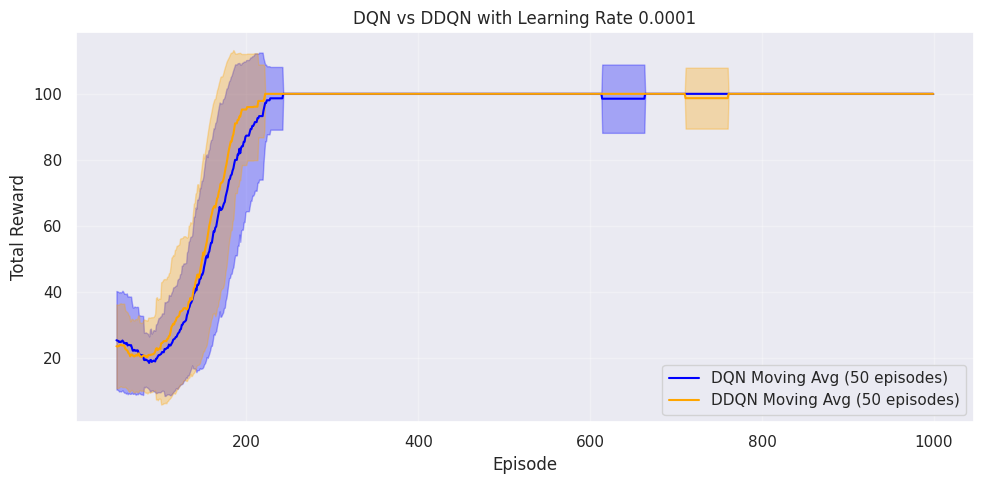

Episode: 100, Mean reward: 24.35, Eps: 0.78
Episode: 200, Mean reward: 55.51, Eps: 0.31
Episode: 300, Mean reward: 98.24, Eps: 0.05
Episode: 400, Mean reward: 99.30, Eps: 0.05
Episode: 500, Mean reward: 96.05, Eps: 0.05
Episode: 600, Mean reward: 98.99, Eps: 0.05
Episode: 700, Mean reward: 99.60, Eps: 0.05
Episode: 800, Mean reward: 99.34, Eps: 0.05
Episode: 900, Mean reward: 99.61, Eps: 0.05
Episode: 1000, Mean reward: 99.93, Eps: 0.05
Episode: 100, Mean reward: 28.55, Eps: 0.74
Episode: 200, Mean reward: 60.14, Eps: 0.23
Episode: 300, Mean reward: 97.42, Eps: 0.05
Episode: 400, Mean reward: 97.02, Eps: 0.05
Episode: 500, Mean reward: 99.12, Eps: 0.05
Episode: 600, Mean reward: 97.24, Eps: 0.05
Episode: 700, Mean reward: 98.32, Eps: 0.05
Episode: 800, Mean reward: 96.93, Eps: 0.05
Episode: 900, Mean reward: 99.60, Eps: 0.05
Episode: 1000, Mean reward: 100.00, Eps: 0.05


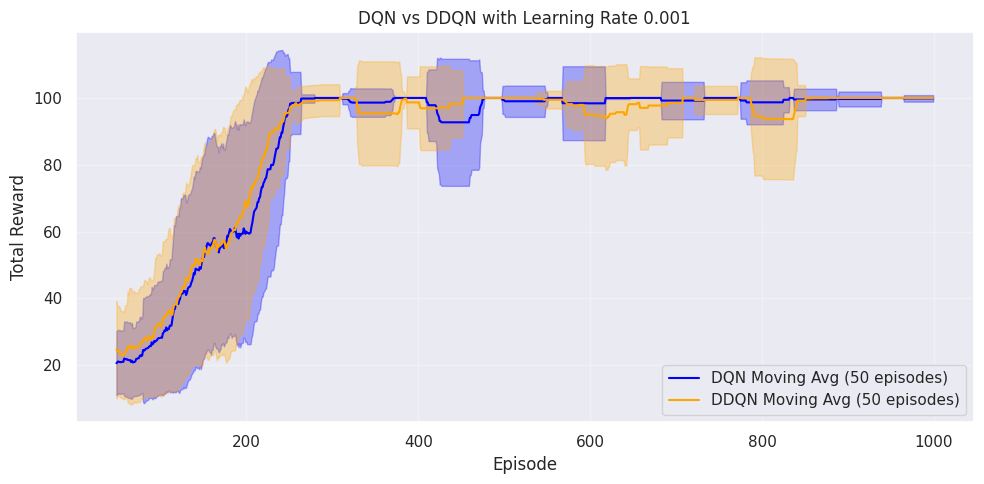

Episode: 100, Mean reward: 23.97, Eps: 0.78
Episode: 200, Mean reward: 30.02, Eps: 0.53
Episode: 300, Mean reward: 37.90, Eps: 0.20
Episode: 400, Mean reward: 87.89, Eps: 0.05
Episode: 500, Mean reward: 90.37, Eps: 0.05
Episode: 600, Mean reward: 93.63, Eps: 0.05
Episode: 700, Mean reward: 95.12, Eps: 0.05
Episode: 800, Mean reward: 81.86, Eps: 0.05
Episode: 900, Mean reward: 84.67, Eps: 0.05
Episode: 1000, Mean reward: 93.98, Eps: 0.05
Episode: 100, Mean reward: 22.02, Eps: 0.80
Episode: 200, Mean reward: 26.54, Eps: 0.57
Episode: 300, Mean reward: 30.59, Eps: 0.31
Episode: 400, Mean reward: 60.55, Eps: 0.05
Episode: 500, Mean reward: 89.47, Eps: 0.05
Episode: 600, Mean reward: 95.54, Eps: 0.05
Episode: 700, Mean reward: 94.52, Eps: 0.05
Episode: 800, Mean reward: 94.89, Eps: 0.05
Episode: 900, Mean reward: 82.65, Eps: 0.05
Episode: 1000, Mean reward: 95.52, Eps: 0.05


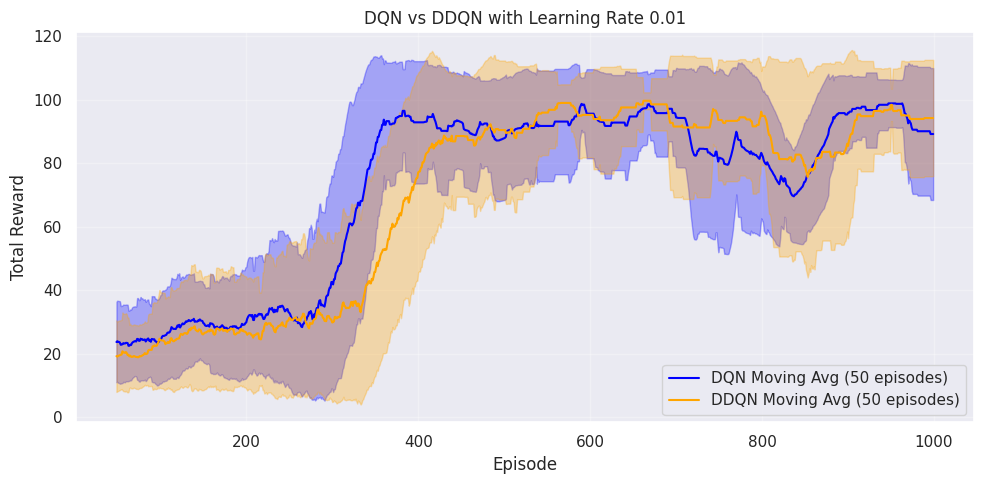

In [11]:
learning_rates = [1e-4, 1e-3, 1e-2]

for lr in learning_rates:
    dqn_env = gym.make("CartPole-v1", max_episode_steps=100)

    dqn_rewards = learning(
        env=dqn_env,                          # gym environmnet
        target_function=dqn_target,      # dqn target construction
        batch_size=128,                   # q-network update batch size
        gamma=0.99,                       # discount factor
        replay_buffer_size=10000,         # size of the replay buffer
        num_episodes=1000,                # number of episodes to run
        learning_starts=1000,             # number of initial random actions (exploration)
        learning_freq=4,                  # frequency of the update
        target_update_freq=100,           # number of gradient steps after which the target network is updated
        log_every=100,                     # logging interval. returns the mean reward per episode.
        learning_rate=lr
    )

    ddqn_env = gym.make("CartPole-v1", max_episode_steps=100)

    ddqn_rewards = learning(
        env=ddqn_env,                          # gym environmnet
        target_function=ddqn_target,     # dqn target construction
        batch_size=128,                   # q-network update batch size
        gamma=0.99,                       # discount factor
        replay_buffer_size=10000,         # size of the replay buffer
        num_episodes=1000,                # number of episodes to run
        learning_starts=1000,             # number of initial random actions  (exploration)
        learning_freq=4,                  # frequency of the update
        target_update_freq=100,           # number of gradient steps after which the target network is updated
        log_every=100,                     # logging interval. returns the mean reward per episode.
        learning_rate=lr
    )

    plot_rewards(dqn_rewards, ddqn_rewards, title=f"DQN vs DDQN with Learning Rate {lr}", save_path=f"./learning_rate/dqn_ddqn_comparison_lr_{lr}.png")

In [ ]:
target_update_freqs = [10, 100, 200]

for target_update_freq in target_update_freqs:
    dqn_env = gym.make("CartPole-v1", max_episode_steps=100)

    dqn_rewards = learning(
        env=dqn_env,                          # gym environmnet
        target_function=dqn_target,      # dqn target construction
        batch_size=128,                   # q-network update batch size
        gamma=0.99,                       # discount factor
        replay_buffer_size=10000,         # size of the replay buffer
        num_episodes=1000,                # number of episodes to run
        learning_starts=1000,             # number of initial random actions (exploration)
        learning_freq=4,                  # frequency of the update
        target_update_freq=target_update_freq,           # number of gradient steps after which the target network is updated
        log_every=100                     # logging interval. returns the mean reward per episode.
    )

    ddqn_env = gym.make("CartPole-v1", max_episode_steps=100)

    ddqn_rewards = learning(
        env=ddqn_env,                          # gym environmnet
        target_function=ddqn_target,     # dqn target construction
        batch_size=128,                   # q-network update batch size
        gamma=0.99,                       # discount factor
        replay_buffer_size=10000,         # size of the replay buffer
        num_episodes=1000,                # number of episodes to run
        learning_starts=1000,             # number of initial random actions  (exploration)
        learning_freq=4,                  # frequency of the update
        target_update_freq=target_update_freq,           # number of gradient steps after which the target network is updated
        log_every=100                     # logging interval. returns the mean reward per episode.
    )

    plot_rewards(dqn_rewards, ddqn_rewards, title=f"DQN vs DDQN with Target Update Freq {target_update_freq}", save_path=f"./target_update_freq/dqn_ddqn_comparison_target_update_freq_{target_update_freq}.png")

In [ ]:
learning_freqs = [1, 4, 8]

for learning_freq in learning_freqs:
    dqn_env = gym.make("CartPole-v1", max_episode_steps=100)

    dqn_rewards = learning(
        env=dqn_env,                          # gym environmnet
        target_function=dqn_target,      # dqn target construction
        batch_size=128,                   # q-network update batch size
        gamma=0.99,                       # discount factor
        replay_buffer_size=10000,         # size of the replay buffer
        num_episodes=1000,                # number of episodes to run
        learning_starts=1000,             # number of initial random actions (exploration)
        learning_freq=learning_freq,                  # frequency of the update
        target_update_freq=100,           # number of gradient steps after which the target network is updated
        log_every=100                     # logging interval. returns the mean reward per episode.
    )

    ddqn_env = gym.make("CartPole-v1", max_episode_steps=100)

    ddqn_rewards = learning(
        env=ddqn_env,                          # gym environmnet
        target_function=ddqn_target,     # dqn target construction
        batch_size=128,                   # q-network update batch size
        gamma=0.99,                       # discount factor
        replay_buffer_size=10000,         # size of the replay buffer
        num_episodes=1000,                # number of episodes to run
        learning_starts=1000,             # number of initial random actions  (exploration)
        learning_freq=learning_freq,                  # frequency of the update
        target_update_freq=100,           # number of gradient steps after which the target network is updated
        log_every=100                     # logging interval. returns the mean reward per episode.
    )

    plot_rewards(dqn_rewards, ddqn_rewards, title=f"DQN vs DDQN with Learning Freq {learning_freq}", save_path=f"./learning_freq/dqn_ddqn_comparison_learning_freq_{learning_freq}.png")

In [ ]:
eps_decay_steps = [5000, 10000, 30000]

for eps_decay_step in eps_decay_steps:
    dqn_env = gym.make("CartPole-v1", max_episode_steps=100)

    dqn_rewards = learning(
        env=dqn_env,                          # gym environmnet
        target_function=dqn_target,      # dqn target construction
        batch_size=128,                   # q-network update batch size
        gamma=0.99,                       # discount factor
        replay_buffer_size=10000,         # size of the replay buffer
        num_episodes=1000,                # number of episodes to run
        learning_starts=1000,             # number of initial random actions (exploration)
        learning_freq=4,                  # frequency of the update
        target_update_freq=100,           # number of gradient steps after which the target network is updated
        log_every=100,                     # logging interval. returns the mean reward per episode.
        eps_decay_steps=eps_decay_step
    )

    ddqn_env = gym.make("CartPole-v1", max_episode_steps=100)

    ddqn_rewards = learning(
        env=ddqn_env,                          # gym environmnet
        target_function=ddqn_target,     # dqn target construction
        batch_size=128,                   # q-network update batch size
        gamma=0.99,                       # discount factor
        replay_buffer_size=10000,         # size of the replay buffer
        num_episodes=1000,                # number of episodes to run
        learning_starts=1000,             # number of initial random actions  (exploration)
        learning_freq=4,                  # frequency of the update
        target_update_freq=100,           # number of gradient steps after which the target network is updated
        log_every=100,                     # logging interval. returns the mean reward per episode.
        eps_decay_steps=eps_decay_step
    )

    plot_rewards(dqn_rewards, ddqn_rewards, title=f"DQN vs DDQN with Eps Decay Steps {eps_decay_step}", save_path=f"./eps_decay_steps/dqn_ddqn_comparison_eps_decay_steps_{eps_decay_step}.png")